In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate

import os
import logging
logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(asctime)s - %(message)s')

import data_extraction as da
import modelling as md
import plotting
from matplotlib.ticker import MaxNLocator
import utils

# TODO: add confirmed genres to ratings table as significantly impact accuracy

Batman V Superman Dawn of Justice subtitles are garbage,
Shang-Chi and the Legend of the Ten Rings,
Minari,
Lincoln,
Boyhood

In [3]:
raw_films_list_df = da.get_or_create_subtitles_data(os.path.join(da.sub_dir, 'movie_index.parquet'), da.sub_dir)
films_list_df = raw_films_list_df[raw_films_list_df.year.ge(2013)].reset_index(drop=True).copy()

full_subs_df_list = []

for movie_cat in ('Blockbusters', 'Oscar'):
    for year in films_list_df.year.unique():
        year_dir = os.path.join(da.sub_by_year_dir, movie_cat, str(year))
        for movie_fp in os.listdir(year_dir):
            curr_df = da.extract_single_subs_file(os.path.join(year_dir, movie_fp))
            full_subs_df_list.append(curr_df)
          
for movie in os.listdir(da.add_sub_dir):
    if movie.endswith('.srt'):
        curr_df = da.extract_single_subs_file(os.path.join(da.add_sub_dir, movie))
        full_subs_df_list.append(curr_df)
    
full_subs_df = pd.concat(full_subs_df_list)

full_subs_df['movie'] = da.clean_movie_name_series(full_subs_df['movie'])
films_list_df['movie'] = da.clean_movie_name_series(films_list_df['movie']).str.replace("'", ' ').str.replace('&', 'and').str.title()

combined_subs_df = full_subs_df.merge(films_list_df, how='left')
combined_subs_df.to_parquet(da.sub_df_dir)

all_transcripts_df_list = []
longitudinal_movies = [utils.remove_ext(x) for x in os.listdir(da.trans_mp3_dir)]

for filename in os.listdir(da.transcript_dir):
    movie = filename.removesuffix(da.transcript_df_fp.format(movie_name=''))
    if movie in longitudinal_movies:
        all_transcripts_df_list.append(pd.read_parquet(os.path.join(da.transcript_dir, filename)))

all_transcripts_df = pd.concat(all_transcripts_df_list)
all_transcripts_df.to_parquet(da.all_transcripts_df_dir)

ValueError: No objects to concatenate

In [ ]:
# All mp3s placed in a sub directory have been filtered out according to the name of their directory
mp3s_list = [x for x in os.walk(da.trans_mp3_dir)]
filtered_movies = [utils.remove_ext(y) for x in mp3s_list[1:] for y in x[2]]

filtered_movies = [x.replace('-', ' ').replace('.', '').title() for x in filtered_movies]

In [ ]:
trans_df = pd.read_parquet(da.all_transcripts_df_dir)
subs_df = pd.read_parquet(da.sub_df_dir)

subs_df['movie'] = subs_df['movie'].str.title()
trans_df['movie_name'] = trans_df['movie_name'].str.strip().str.replace('-', ' ').str.replace('.', '').str.title()

trans_df['text_len'] = trans_df.text.str.len()
text_count = trans_df.groupby('movie_name').text_len.sum().reset_index()

# Add the Dead Lands since we want it accessible for narrator STT testing (all English) but can't use it for prediction (mixed language subtitles)
poorly_transcribed_movies = text_count[text_count.text_len < 7000].movie_name.to_list() + ['The Dead Lands']

trans_df = trans_df[~trans_df.movie_name.isin(poorly_transcribed_movies)].reset_index(drop=True)
filtered_movies += poorly_transcribed_movies

In [ ]:
text_count.sort_values('text_len')

,movie_name,text_len
381,Rbg,7507
544,Whitney Can I Be Me,9454
42,Annie Hall,9752
518,The Trial Of The Chicago 7,9792
468,The Gospel According To Andre,10105
...,...,...
425,Star Wars Episode Viii The Last Jedi,84182
61,Batman V Superman Dawn Of Justice,84854
151,Dune,85316
78,Blade Runner 2049,89560


In [ ]:
red_trans_df = trans_df[trans_df.text.ne(' Thank you.') & trans_df.text.ne('')].copy().reset_index(drop=True)
red_trans_df['start_time'] = pd.to_timedelta(red_trans_df['uncut_start'], unit='s')
red_trans_df['end_time'] = pd.to_timedelta(red_trans_df['uncut_end'], unit='s')
red_trans_df = red_trans_df[['start_time', 'end_time', 'movie_name', 'text']].rename(columns={'movie_name': 'movie'}) #[red_trans_df.uncut_start.notna()]
red_trans_df['type'] = 'narration'

filtered_subs_df = subs_df[subs_df.movie.isin(trans_df['movie_name'].unique())].copy().reset_index(drop=True)
filtered_subs_df['text'] = filtered_subs_df['raw_dialogue'].apply(da.remove_html)
filtered_subs_df = filtered_subs_df[['start_time', 'end_time', 'movie', 'text']]
filtered_subs_df['type'] = 'dialogue'

full_txt_df = pd.concat([red_trans_df, filtered_subs_df])

/home/raine-bianchini/Documents/projects/honours/audiodescription-abusedetection/data_extraction.py:120: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  return BeautifulSoup(text, 'html.parser').get_text(separator=' ')


In [ ]:
# Check transcriptions missing subtitles
extra_subs = [utils.remove_ext(x).title() for x in os.listdir(da.add_sub_dir)]
set(trans_df.movie_name.unique()).difference(set(list(subs_df.movie) + extra_subs))

{'Chariots Of Fire',
 'Girl In The Closet',
 'Legends Of The Hidden Temple',
 'The Adventures Of Sharkboy And Lavagirl',
 'The Departed',
 'The Last Screenwriter',
 'The Silence Of The Lambs'}

In [ ]:
# Check subtitles for missing transcriptions
set(subs_df[subs_df.year.ge(2013)].movie).difference(set(list(trans_df.movie_name.unique()) + filtered_movies))

{'Amour',
 'Demon Slayer Kimetsu No Yaiba   The Movie Mugen Train',
 'Detective Chinatown 3',
 'Hi, Mom',
 'Jiang Ziya',
 'My People, My Homeland',
 'Roma',
 'The Battle At Lake Changjin',
 'The Eight Hundred',
 'Triangle Of Sadness',
 'Water Gate Bridge',
 'Wolf Warrior 2'}

In [ ]:
raw_acb_df = da.get_acb_film_ratings()
acb_df = raw_acb_df[raw_acb_df.themes.notna()].drop(columns=['url', 'consumer_advice']).reset_index(drop=True)
acb_df['movie'] = acb_df['movie'].str.replace(':', '').str.replace('-', ' ').str.replace('.', '').str.title()
acb_df = acb_df[~acb_df.movie.isin(filtered_movies)]
full_txt_w_acb_df = full_txt_df.merge(acb_df)
full_txt_w_acb_df.to_parquet(da.cleaned_dataset_fp)

In [48]:
full_txt_w_acb_df = pd.read_parquet(da.cleaned_dataset_fp) #.groupby(['movie', 'type'])
full_txt_w_acb_df = full_txt_w_acb_df[full_txt_w_acb_df['text'].ne('')]
full_txt_w_acb_df['word_len'] = [len(x.split()) for x in full_txt_w_acb_df['text'].tolist()]
table_df = full_txt_w_acb_df.groupby(['movie', 'type']).word_len.sum().reset_index().groupby('type').agg({
    'word_len': [('document_count', 'count'), ('mean_word_count', 'mean'), ('stdev_word_count', 'std')]
}).round(1).reset_index()
table_df.columns = ['Text Type', 'Films', 'Avg Word Count', 'St Dev. Word Count']
table_df

,Text Type,Films,Avg Word Count,St Dev. Word Count
0,dialogue,550,9639.5,3401.4
1,narration,550,6849.1,2942.9


In [49]:
latex_table = tabulate(table_df, headers='keys', tablefmt='latex', showindex=False)
with open(os.path.join(plotting.output_dir, 'Document Summary.tex'), 'w') as fileobj:
    fileobj.write(latex_table)

In [31]:
# Check Full Text Films which are missing an ACB rating
set(full_txt_df['movie'].unique()).difference(set(acb_df['movie'].unique()))

{'Annie Hall',
 'Chariots Of Fire',
 'Girl In The Closet',
 'Legends Of The Hidden Temple',
 'The Adventures Of Sharkboy And Lavagirl',
 'The Departed',
 'The Last Screenwriter',
 'The Silence Of The Lambs'}

In [32]:
# Check Ratings that are missing movie text
set(acb_df['movie'].unique()).difference(set(list(full_txt_df['movie'].unique()) + filtered_movies))

set()

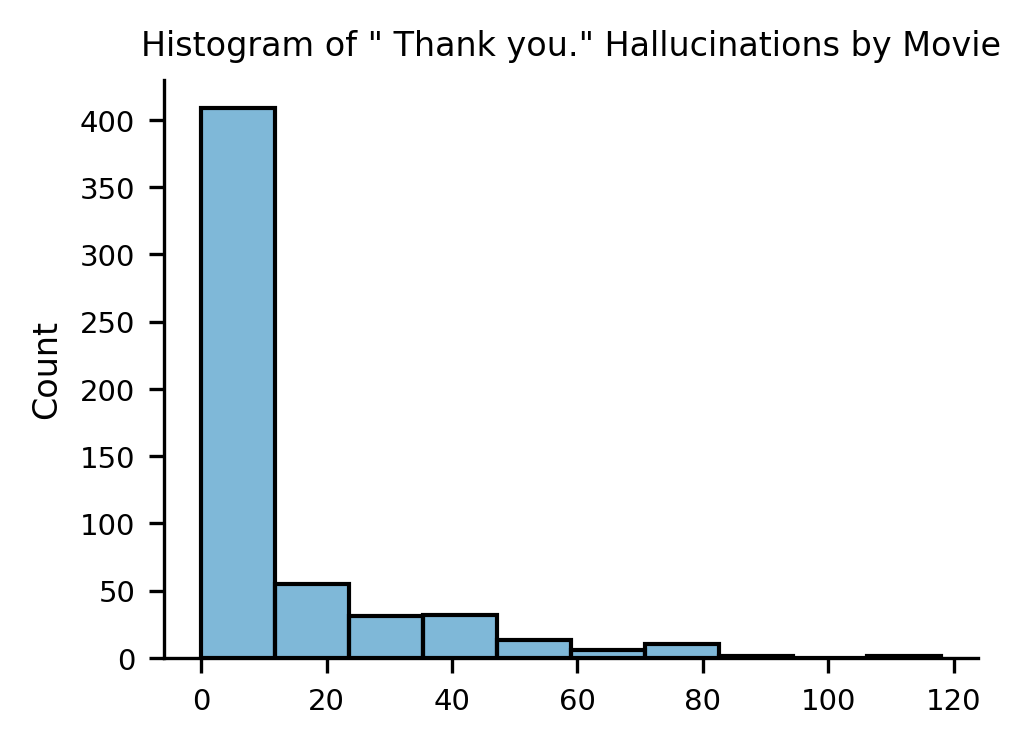

In [33]:
plotting.create_thank_you_hist(trans_df)
sns.despine()
# TODO: consider evaluating per segment count or per character count

In [34]:
thank_you_count = trans_df[trans_df.text.eq(' Thank you.')] \
    .groupby('movie_name') \
    .text.count() \
    .reset_index() \
    .rename(columns={'text': 'count'}) \
    .sort_values('count', ascending=False)
thank_you_count.iloc[:10]

,movie_name,count
226,Spider Man No Way Home,118
111,Girl In The Closet,86
299,Top Gun Maverick,81
307,We'Re The Millers,80
163,Licorice Pizza,79
279,The Nice Guys,75
94,Fast10,74
210,Saturday Night,73
282,The Power Of The Dog,73
291,The Wedding Ringer,73


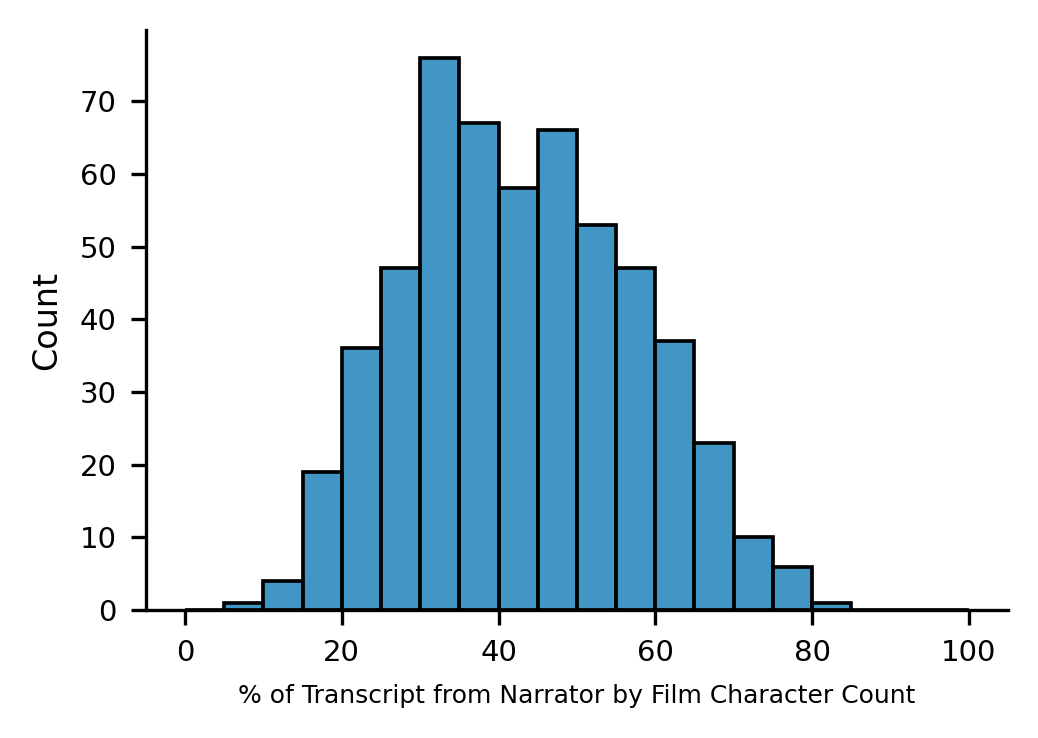

In [35]:
trans_wc_df = red_trans_df.groupby('movie').text.apply(' '.join).apply(len)
subs_wc_df = filtered_subs_df.groupby('movie').text.apply(' '.join).apply(len)

perc_narration_df = trans_wc_df / (subs_wc_df + trans_wc_df) * 100

sns.histplot(perc_narration_df, binrange=(0, 100), bins=20)
plt.xlabel('% of Transcript from Narrator by Film Character Count', fontsize=6)
sns.despine()
plt.tight_layout()
plotting.savefig('Narrator Proportion Histogram')
plt.show()

In [36]:
perc_narration_df.sort_values(ascending=False).iloc[:5]

movie
The Substance                     82.482086
Dunkirk                           78.267728
The Apparition                    77.568205
Dawn Of The Planet Of The Apes    77.549676
Mad Max Fury Road                 77.414725
Name: text, dtype: float64

In [37]:
perc_narration_df.sort_values(ascending=True).iloc[:5]

movie
The Trial Of The Chicago 7        9.292453
Rbg                              10.650640
The Gospel According To Andre    12.121212
Annie Hall                       12.140161
The Sparks Brothers              14.614043
Name: text, dtype: float64

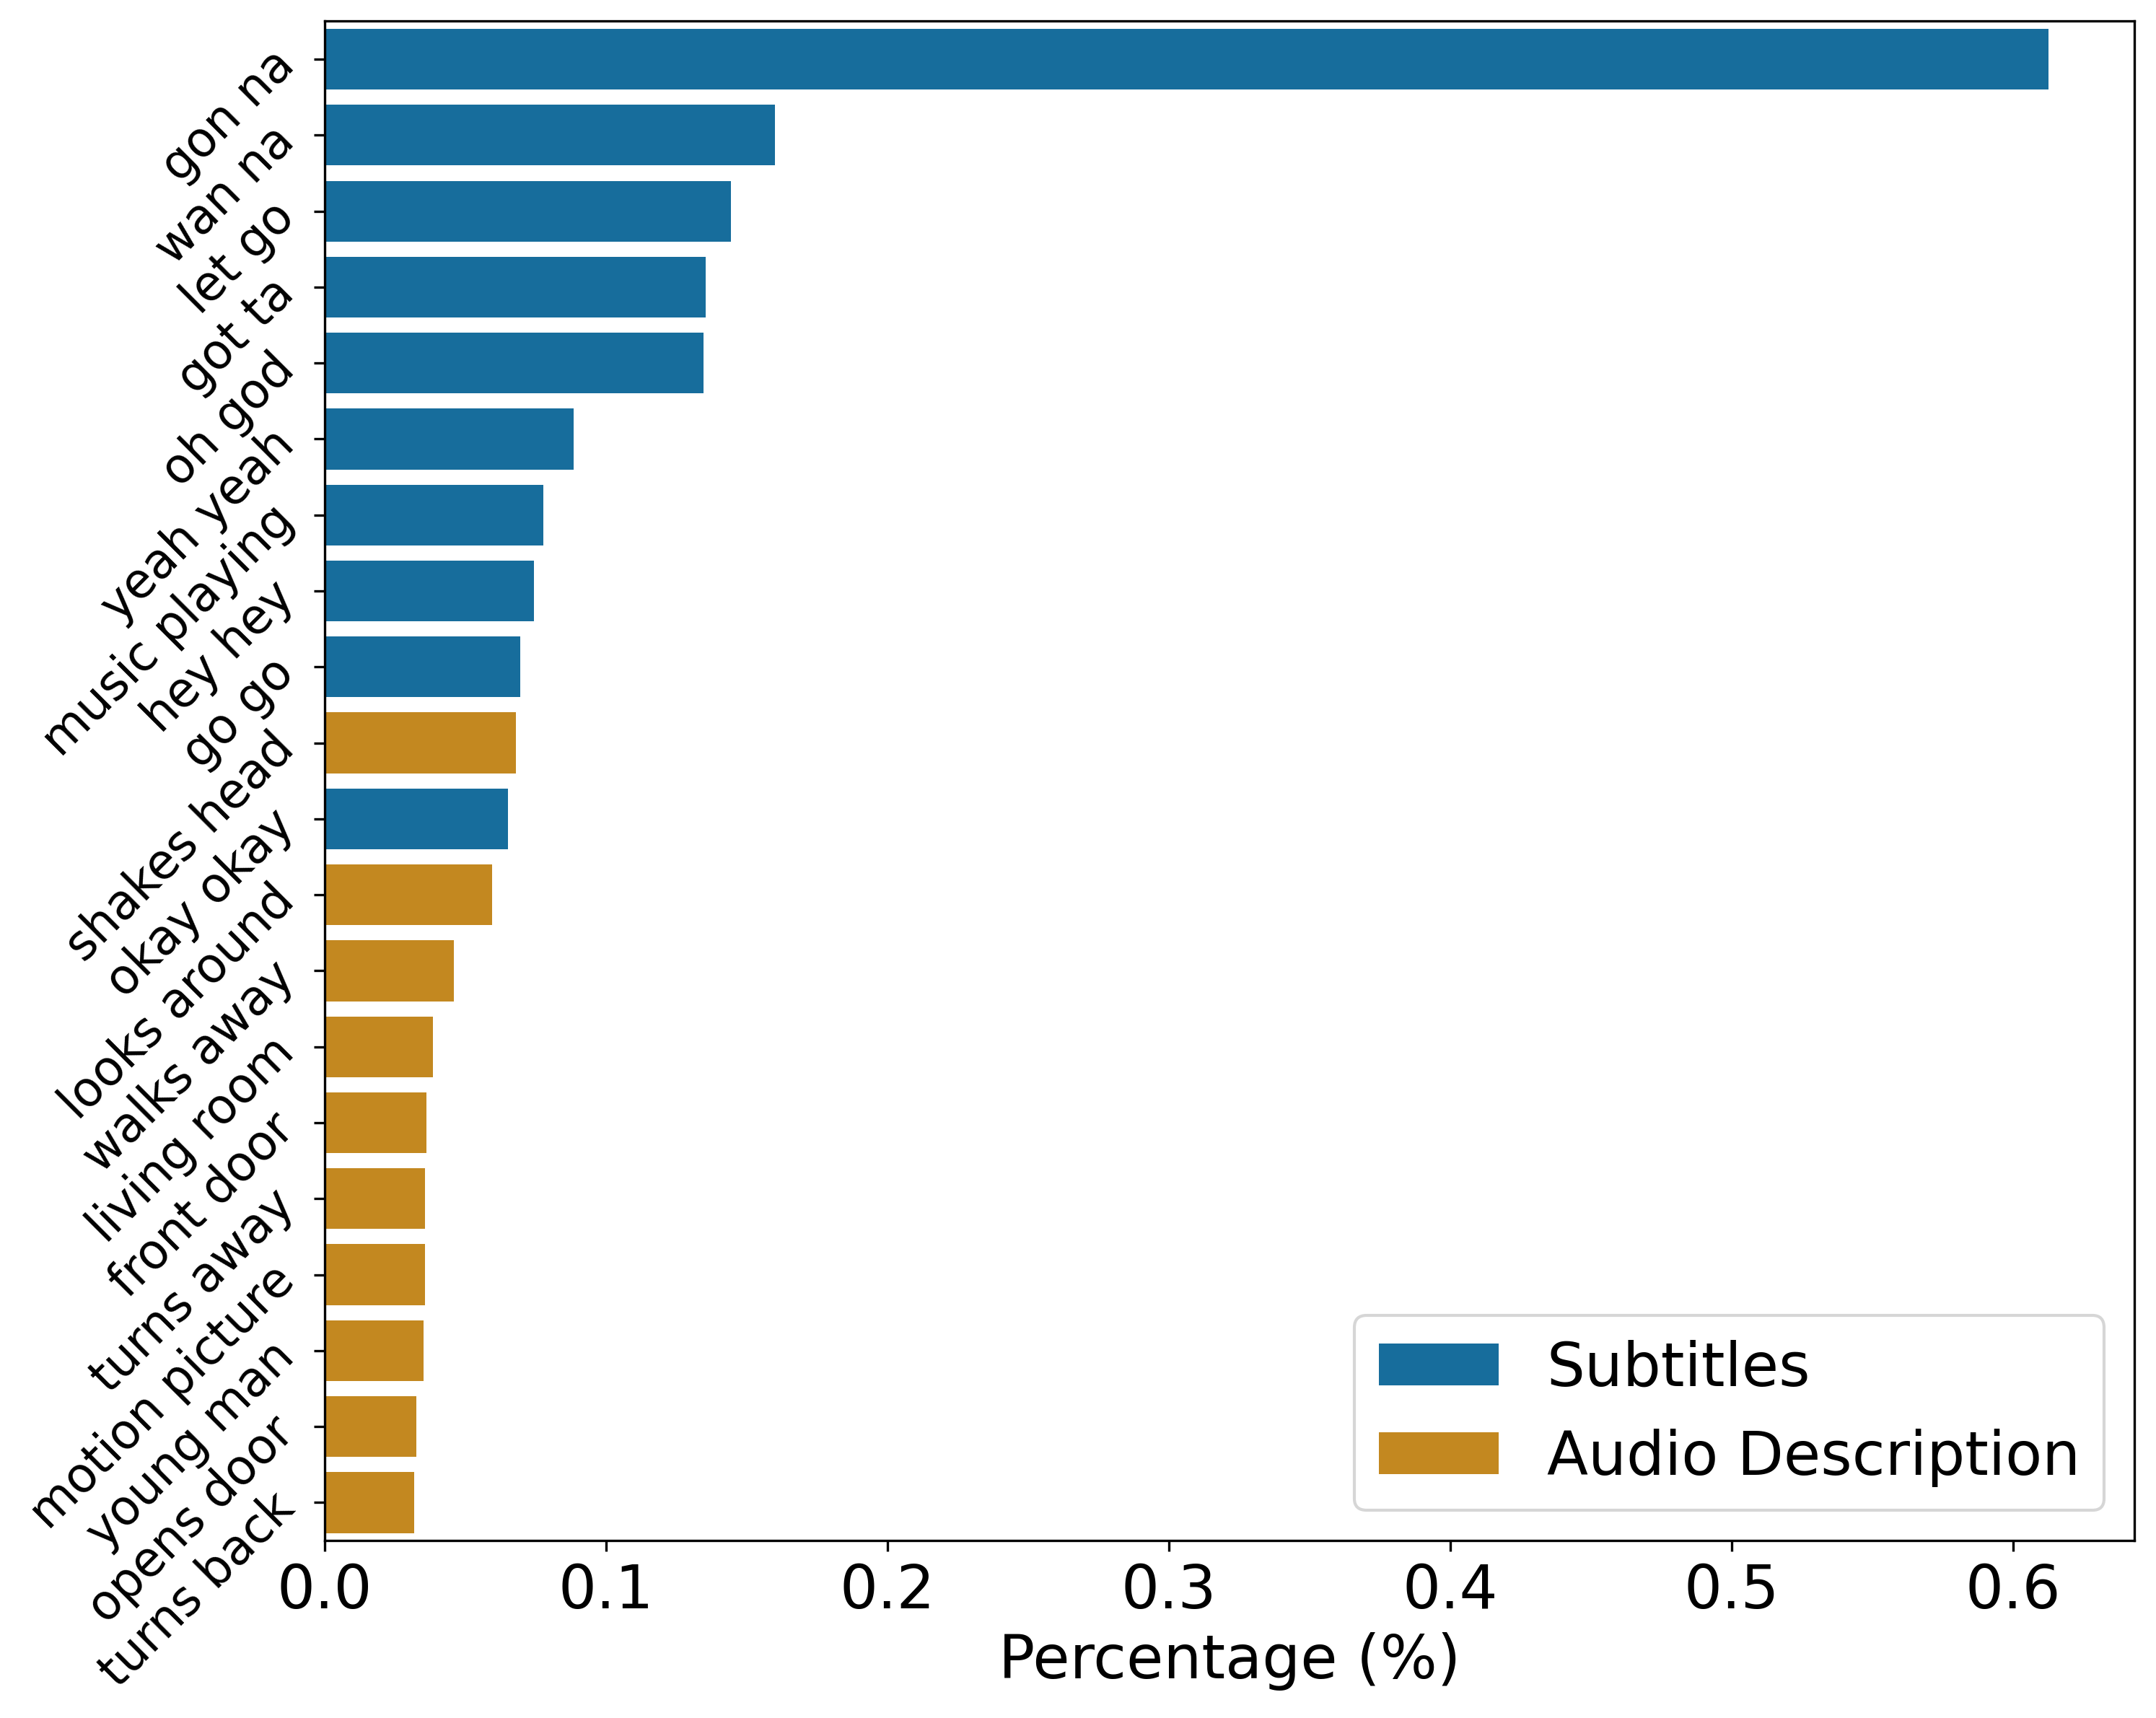

In [38]:
subs_text = ' '.join(filtered_subs_df.text)
sub_bigram_df = md.get_ngram_counts(subs_text, 2, excl_stopwords=True)
sub_bigram_df['Type'] = 'Subtitles'

trans_text = ' '.join(red_trans_df.text)
trans_bigram_df = md.get_ngram_counts(trans_text, 2, excl_stopwords=True)
trans_bigram_df['Type'] = 'Audio Description'

full_title = f"Bigram Frequencies for Subtitles and Audio Description"
full_bigram_df = pd.concat([sub_bigram_df, trans_bigram_df]).sort_values('Percentage', ascending=False)
plotting.plot_ngrams(full_bigram_df, full_title, os.path.join(plotting.output_dir, f'{full_title}.png'))

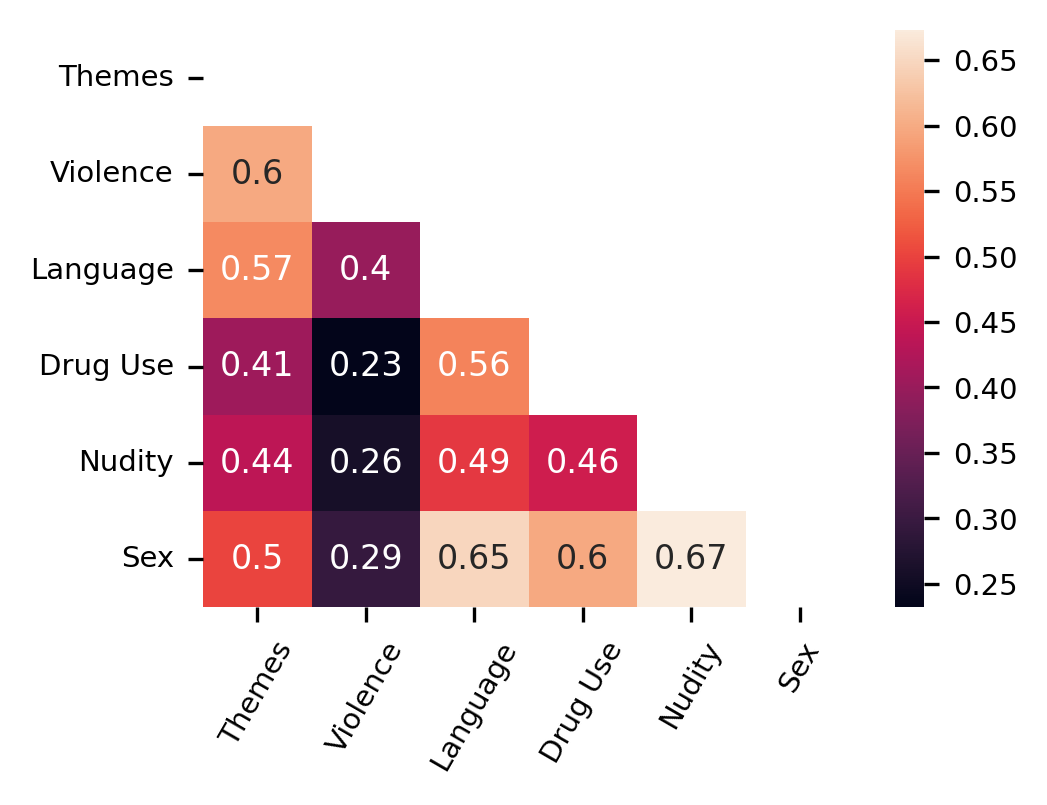

In [ ]:
full_ord_acb_df = acb_df.copy()
for col in md.full_cat_cols:
    full_ord_acb_df[col] = md.convert_col_to_ordinal(full_ord_acb_df[col], compact=False)

corr_df = full_ord_acb_df[md.full_cat_cols].corr()
matrix = np.triu(corr_df)
labels = [x.title().replace('_', ' ') for x in md.full_cat_cols]
sns.heatmap(corr_df, annot=True, mask=matrix, xticklabels=labels, yticklabels=labels)
# plt.title('Correlation of Ratings Categories')
plt.xticks(rotation=60)
plotting.savefig('Ratings Heatmap')
plt.show()

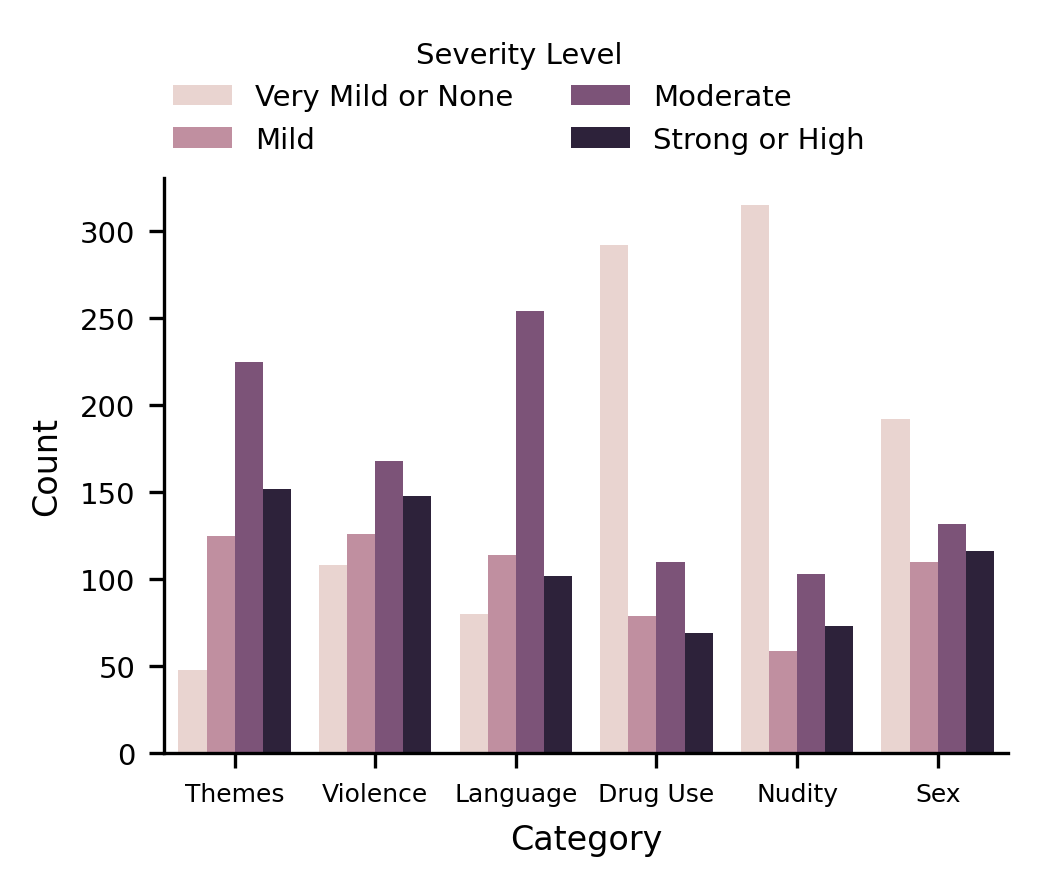

In [40]:
ord_acb_df = acb_df.copy()
for col in md.full_cat_cols:
    ord_acb_df[col] = md.convert_col_to_ordinal(ord_acb_df[col], compact=True)

melt_df = pd.melt(ord_acb_df, ['movie'], md.full_cat_cols)
melt_df['Category'] = melt_df['variable'].str.title().str.replace('_', ' ')
g = sns.countplot(melt_df, x='Category', hue='value')
txt_labels = ['Very Mild or None', 'Mild', 'Moderate', 'Strong or High']
plt.ylabel('Count')
plt.xticks(fontsize=6)
sns.despine()
plt.tight_layout()
plotting.place_legend_ontop_of_graph(g, is_catplot=False, legend_title='Severity Level', ncol=2, txt_labels=txt_labels)
plotting.savefig('Dataset Cat Distribution')
plt.show()
# plt.title('Counts per Aggregated Rating Category')

/tmp/ipykernel_213835/2013944403.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.countplot(full_ord_acb_df, x='Classification', palette=plotting.full_acb_palette[1:], order=md.classifications)


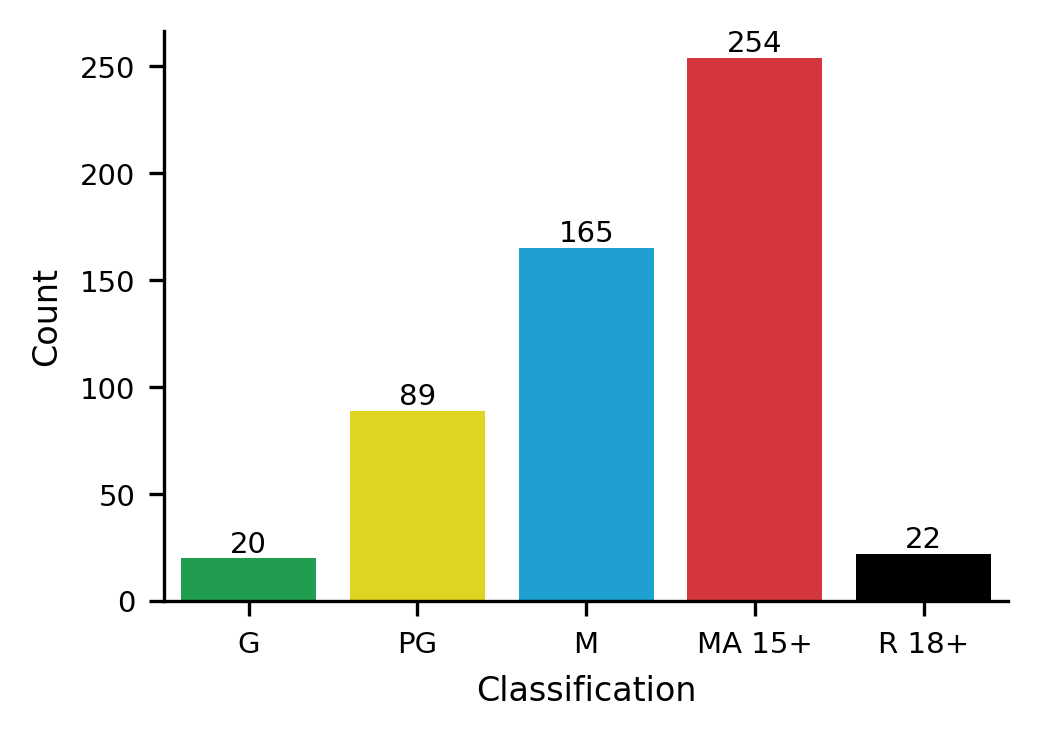

In [52]:
full_ord_acb_df['rating'] = full_ord_acb_df[md.full_cat_cols].max(axis=1)
full_ord_acb_df['Classification'] = np.select(
    [full_ord_acb_df['rating'].eq(ii) for ii in range(1, 6)],
    md.classifications,
    default=md.classifications[0]
)

g = sns.countplot(full_ord_acb_df, x='Classification', palette=plotting.full_acb_palette[1:], order=md.classifications)
plt.ylabel('Count')
sns.despine()

[g.axes.bar_label(g.axes.containers[ii], fontsize=7) for ii in range(full_ord_acb_df.Classification.nunique())]
plt.tight_layout()
plotting.savefig('Dataset Classification Count Plot')
plt.show()

INFO - 2025-07-21 23:38:55,069 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO - 2025-07-21 23:38:55,071 - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


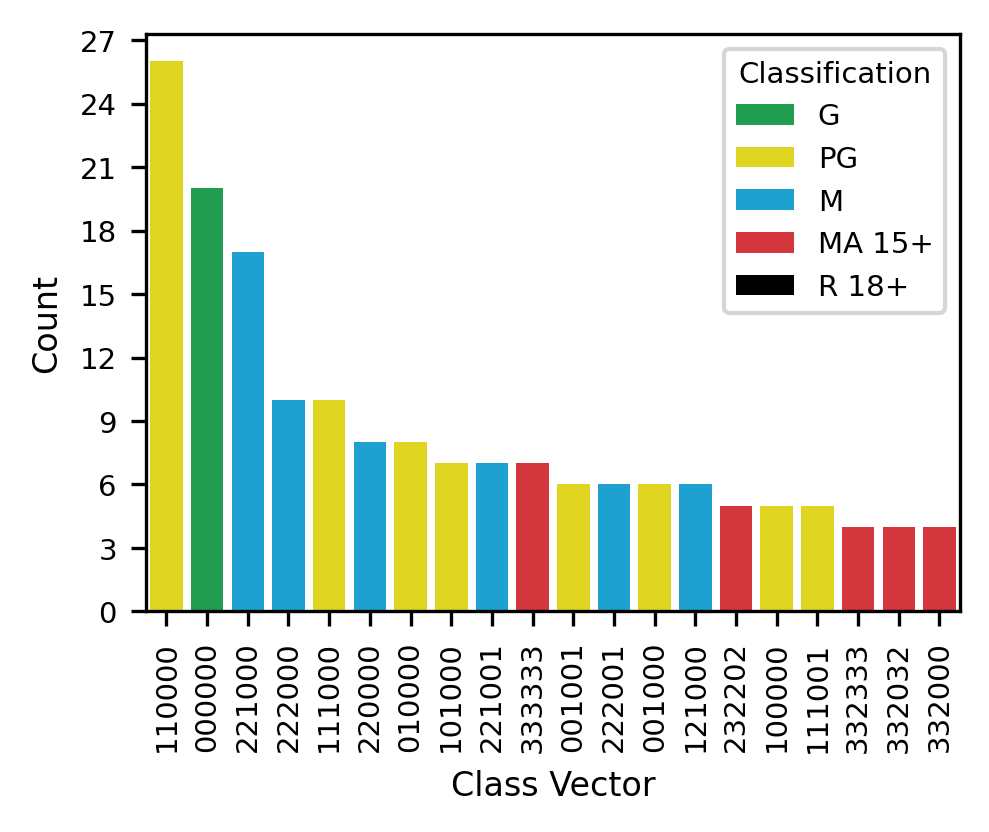

In [42]:
n=20
ord_acb_df['overall_code'] = ord_acb_df[md.full_cat_cols].astype(str).agg(''.join, axis=1)
ord_acb_df['rating'] = ord_acb_df[md.full_cat_cols].max(axis=1)
ord_acb_df['Classification'] = np.select(
    [ord_acb_df['rating'].eq(ii) for ii in range(len(md.classifications))],
    md.classifications,
    default='Error'
)
top_codes = ord_acb_df['overall_code'].value_counts()

top_n_codes = ord_acb_df[ord_acb_df.overall_code.isin(top_codes.index[:n])]
fig = sns.countplot(top_n_codes, x='overall_code', hue='Classification', hue_order=md.classifications, order=top_codes.index[:n], palette=plotting.full_acb_palette[1:])
plt.xticks(rotation=90)
fig.axes.yaxis.set_major_locator(MaxNLocator(integer=True))
plt.xlabel('Class Vector')
plt.ylabel('Count')
plotting.savefig(f'Class Vector Frequency Top {n}')
plt.show()